# Generative AI Skill Extraction from Job Postings
**Author:** Niat Kahsay  
**Project:** Job Market Analysis  
**Dataset:** jobs_combined_dedup.csv

## Introduction

In this notebook, I use a Large Language Model (Groq) to extract structured skills
from job descriptions collected by our team. Unlike traditional keyword-based methods
(like TF - IDF), generative AI can understand context — meaning it can identify skills
even when they're described indirectly rather than explicitly listed.

The goal of this notebook is to:
- Use Groq to extract technical skills from each job posting
- Save and organize those extracted skills as structured data
- Compare the GenAI results against Kiara's TF-IDF/keyword baseline
- Reflect on the effectiveness, limitations, and ethical considerations of using GenAI for this task

In [2]:
# import libraries
!pip install google-generativeai -q

import pandas as pd
import google.generativeai as genai
import time
import re
import ast

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [4]:
#load dataset
df = pd.read_csv('/content/jobs_combined_dedup.csv')

# preview the data
print(df.shape)
df.head()

(200, 11)


,source,search_term,title,company,location,date_posted,job_type,description,job_url,text,rn
0,indeed,data scientist,"Senior Partner Engineer, Snowflake Alliance",Sigma Computing,"San Francisco, CA, US",2026-02-01,fulltime,"A Senior Partner Engineer, Snowflake Alliance ...",https://www.indeed.com/viewjob?jk=0cf355b8857e...,"senior partner engineer, snowflake alliance a ...",1
1,indeed,data scientist,"Senior Software Development Engineer, AI/ML, A...",Amazon Web Services,"Cupertino, CA, US",2025-08-06,fulltime,**DESCRIPTION** --------------- The Annapurna ...,https://www.indeed.com/viewjob?jk=2637ee92463b...,"senior software development engineer, ai/ml, a...",1
2,indeed,data scientist,"DS, Applied Science , Amazon",Amazon.com,"Palo Alto, CA, US",2025-06-16,fulltime,**DESCRIPTION** --------------- The charter of...,https://www.indeed.com/viewjob?jk=817560deb175...,"ds, applied science , amazon **description** -...",1
3,indeed,data scientist,"Applied Scientist, Prime Video - Personalizati...",Amazon.com,"Sunnyvale, CA, US",2025-07-08,fulltime,**DESCRIPTION** --------------- Prime Video is...,https://www.indeed.com/viewjob?jk=9e60c1168371...,"applied scientist, prime video - personalizati...",1
4,indeed,data scientist,"Sr. Applied Scientist, AGI Info",Amazon.com,"Sunnyvale, CA, US",2025-06-04,fulltime,**DESCRIPTION** --------------- Amazon’s Artif...,https://www.indeed.com/viewjob?jk=b4f7a886617a...,"sr. applied scientist, agi info **description*...",1


In [16]:
#set up LLaMA model though Groq API
!pip install groq -q

from groq import Groq

client = Groq(api_key="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")

# Quick test
response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": "Say hello!"}]
)
print(response.choices[0].message.content)

Hello. Is there something I can help you with or would you like to chat?


In [19]:
#prompt engineering
import json

def build_prompt(job_description):
    return f"""You are extracting structured technical skills from a job description.

Instructions:
- Extract only concrete, job-relevant technical skills.
- Include programming languages, tools, frameworks, platforms, libraries, databases, cloud services, methodologies, and certifications.
- Exclude soft skills (e.g., communication, teamwork, leadership).
- Exclude generic phrases (e.g., "problem solving", "fast paced environment").
- Normalize skills to lowercase.
- Use canonical names when possible (e.g., "amazon web services" -> "aws", "structured query language" -> "sql").
- Remove duplicates.
- Do not infer skills that are not explicitly stated.
- Return output as valid JSON.
- Return ONLY valid JSON. Do not include commentary. Do not wrap output in markdown. Do not include trailing commas.

Output format:
{{
  "skills": ["skill_1", "skill_2", "skill_3"]
}}

Job Description:
\"\"\"
{job_description[:1000]}
\"\"\"
"""

In [20]:
#extracting skills using LLaMA
results = []

for i, row in df.iterrows():
    try:
        prompt = build_prompt(row["description"])
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}]
        )
        raw = response.choices[0].message.content.strip()
        parsed = json.loads(raw)
        skills_list = parsed["skills"]
        skills_str = ", ".join(skills_list)

        results.append({
            "raw_response": raw,
            "parsed_skills": skills_list,
            "ai_skills": skills_str
        })
        print(f"Row {i} ✓: {skills_str[:80]}...")

    except Exception as e:
        print(f"Row {i} ✗ failed: {e}")
        results.append({
            "raw_response": None,
            "parsed_skills": None,
            "ai_skills": None
        })

    time.sleep(0.5)

df["raw_response"] = [r["raw_response"] for r in results]
df["parsed_skills"] = [r["parsed_skills"] for r in results]
df["ai_skills"] = [r["ai_skills"] for r in results]

print("\nDone! Preview:")
df[["title", "company", "ai_skills"]].head()

Row 0 ✓: ...
Row 1 ✓: aws, deep learning, genai, machine learning, inferentia, trainium, ml accelerato...
Row 2 ✓: generative ai, large language models, sql...
Row 3 ✓: aws, c++, c++11, sql, apache spark, apache Cassandra, scala, apache flink...
Row 4 ✓: python, aws, ageneral intelligence, amazon, information retrieval, web-scale, sq...
Row 5 ✓: amazon web services, aws, linux, python, java, c++, git, sql, mongodb, postgresq...
Row 6 ✓: ...
Row 7 ✓: amazon aws, decentralized training, deep learning, geospatial data, image proces...
Row 8 ✓: ...
Row 9 ✓: machine learning, data scientist, data engineer, business strategist, sql...
Row 10 ✓: sql, python, advanced analytics, machine learning, data scientist, aws, docker, ...
Row 11 ✓: aws, python, sql, machine learning, large language models, pretraining, post-tra...
Row 12 ✓: aws, java, kotlin, python, c++, sql, aws lambda, aws api gateway, aws cloudforma...
Row 13 ✓: aws, generative ai, go to market, genai models, sql, amazon web service

,title,company,ai_skills
0,"Senior Partner Engineer, Snowflake Alliance",Sigma Computing,
1,"Senior Software Development Engineer, AI/ML, A...",Amazon Web Services,"aws, deep learning, genai, machine learning, i..."
2,"DS, Applied Science , Amazon",Amazon.com,"generative ai, large language models, sql"
3,"Applied Scientist, Prime Video - Personalizati...",Amazon.com,"aws, c++, c++11, sql, apache spark, apache Cas..."
4,"Sr. Applied Scientist, AGI Info",Amazon.com,"python, aws, ageneral intelligence, amazon, in..."


In [21]:
#save extracted columns
df.to_csv("jobs_with_ai_skills.csv", index=False)
print("Saved successfully!")
print(f"Total rows: {len(df)}")
print(f"Successful extractions: {df['ai_skills'].notna().sum()}")
print(f"Failed extractions: {df['ai_skills'].isna().sum()}")

Saved successfully!
Total rows: 200
Successful extractions: 194
Failed extractions: 6


Now that we have extracted skills using LLaMA through Groq, we compare our
results against our (Kiara's) TF-IDF baseline analysis.

TF-IDF is a traditional text mining method that identifies important words
based on how often they appear across documents. It does not understand context
 it simply counts and weighs words mathematically.

Our GenAI approach uses a large language model that reads and understands the
full meaning of each job description, extracting skills even when they are
described indirectly.

By comparing both methods we can answer:
- What skills did both methods agree on?
- What did GenAI find that TF-IDF missed?
- What did TF-IDF find that GenAI missed?

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# TF-IDF top keywords (from Kiara's notebook)
kiara_tfidf_keywords = [
    "experience", "data", "amazon", "ai", "work", "team", "prime",
    "learning", "position", "including", "models", "customers", "video",
    "job", "duties", "business", "solutions", "ml", "qualifications",
    "machine", "include", "listed", "applicants", "company", "science"
]

# extract all AI skills from our results into one big list
all_ai_skills = []
for skills_str in df["ai_skills"].dropna():
    skills = [s.strip().lower() for s in skills_str.split(",")]
    all_ai_skills.extend(skills)

# count most common AI-extracted skills
ai_skill_counts = Counter(all_ai_skills)
ai_top = pd.DataFrame(ai_skill_counts.most_common(25), columns=["skill", "count"])

print("Top 25 AI-Extracted Skills:")
print(ai_top)

Top 25 AI-Extracted Skills:
                          skill  count
0                           sql    104
1                           aws     77
2                        python     71
3                                   53
4              machine learning     52
5                            ai     28
6                          java     21
7           amazon web services     19
8                    kubernetes     19
9                        docker     18
10                           ml     16
11                 data science     15
12                   tensorflow     12
13                          c++     11
14                      pytorch     10
15                generative ai     10
16                        linux     10
17                   postgresql     10
18                   aws lambda     10
19        large language models      8
20                          git      8
21                    terraform      8
22  natural language processing      8
23                deep learning     

In [24]:
from collections import Counter

# TF-IDF top keywords from her baseline analysis
kiara_tfidf_keywords = [
    "experience", "data", "amazon", "ai", "work", "team", "prime",
    "learning", "position", "including", "models", "customers", "video",
    "job", "duties", "business", "solutions", "ml", "qualifications",
    "machine", "include", "listed", "applicants", "company", "science"
]

# extract all AI-extracted skills into one big list
all_ai_skills = []
for skills_str in df["ai_skills"].dropna():
    skills = [s.strip().lower() for s in skills_str.split(",")]
    all_ai_skills.extend(skills)

# count most common AI-extracted skills
ai_skill_counts = Counter(all_ai_skills)
ai_top = pd.DataFrame(ai_skill_counts.most_common(25), columns=["skill", "count"])

print("Top 25 AI-Extracted Skills:")
print(ai_top)

Top 25 AI-Extracted Skills:
                          skill  count
0                           sql    104
1                           aws     77
2                        python     71
3                                   53
4              machine learning     52
5                            ai     28
6                          java     21
7           amazon web services     19
8                    kubernetes     19
9                        docker     18
10                           ml     16
11                 data science     15
12                   tensorflow     12
13                          c++     11
14                      pytorch     10
15                generative ai     10
16                        linux     10
17                   postgresql     10
18                   aws lambda     10
19        large language models      8
20                          git      8
21                    terraform      8
22  natural language processing      8
23                deep learning     

The bar chart below shows the 25 most frequently extracted skills across
all 200 job postings. This gives us a high-level view of what the AI
model identified as the most in-demand technical skills in the job market.

/tmp/ipython-input-402542914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ai_top, x="count", y="skill", palette="viridis")


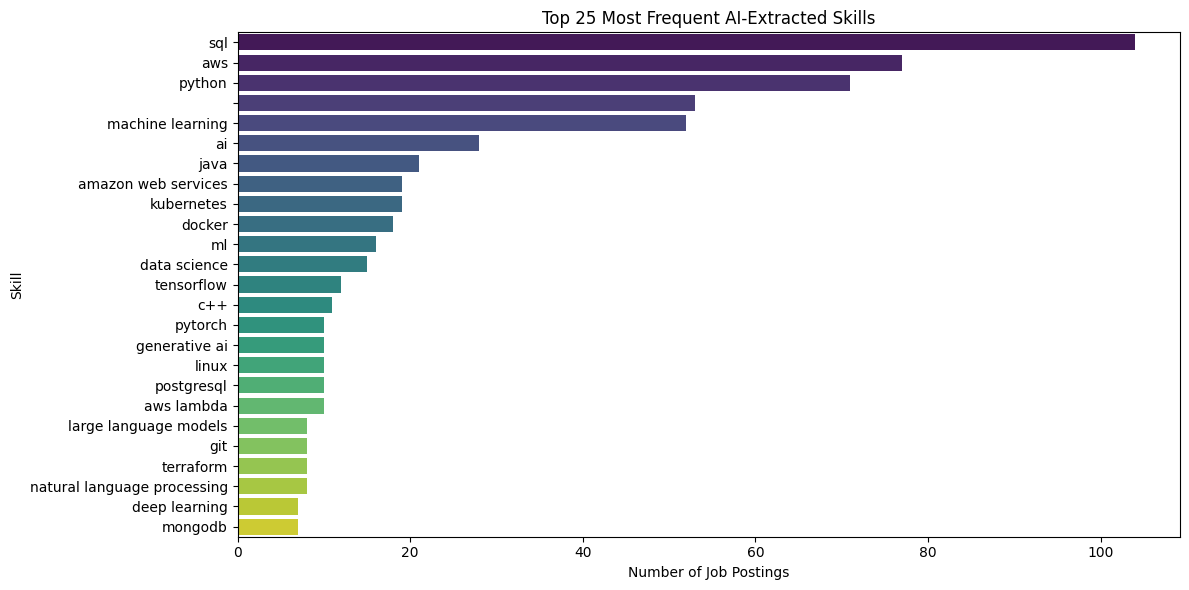

In [26]:
plt.figure(figsize=(12,6))
sns.barplot(data=ai_top, x="count", y="skill", palette="viridis")
plt.title("Top 25 Most Frequent AI-Extracted Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()


### Overlap Between GenAI and TF-IDF

Here we identify which skills appeared in BOTH the AI extraction results
and Kiara's TF-IDF keywords. High overlap means both methods agree
these are the most confidently identified important terms.

We also identify what each method found uniquely, which helps us understand
the strengths and limitations of each approach.

In [28]:
# get top 25 AI skills as a set
ai_top_set = set(ai_top["skill"].tolist())
kiara_set = set(kiara_tfidf_keywords)

# find overlap and differences
overlap = ai_top_set.intersection(kiara_set)
only_ai = ai_top_set.difference(kiara_set)
only_tfidf = kiara_set.difference(ai_top_set)

print(f"Skills found by BOTH methods ({len(overlap)}):")
print(sorted(overlap))

print(f"\n Skills found ONLY by GenAI ({len(only_ai)}):")
print(sorted(only_ai))

print(f"\n Keywords found ONLY by TF-IDF ({len(only_tfidf)}):")
print(sorted(only_tfidf))

Skills found by BOTH methods (2):
['ai', 'ml']

 Skills found ONLY by GenAI (23):
['', 'amazon web services', 'aws', 'aws lambda', 'c++', 'data science', 'deep learning', 'docker', 'generative ai', 'git', 'java', 'kubernetes', 'large language models', 'linux', 'machine learning', 'mongodb', 'natural language processing', 'postgresql', 'python', 'pytorch', 'sql', 'tensorflow', 'terraform']

 Keywords found ONLY by TF-IDF (23):
['amazon', 'applicants', 'business', 'company', 'customers', 'data', 'duties', 'experience', 'include', 'including', 'job', 'learning', 'listed', 'machine', 'models', 'position', 'prime', 'qualifications', 'science', 'solutions', 'team', 'video', 'work']


### Visualizing the Overlap

The bar chart below directly compares how many skills each method found
uniquely versus how many they shared. This gives us a quick visual summary
of where the two approaches agree and diverge.

/tmp/ipython-input-4100351672.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_summary, x="Category", y="Count", palette="coolwarm")


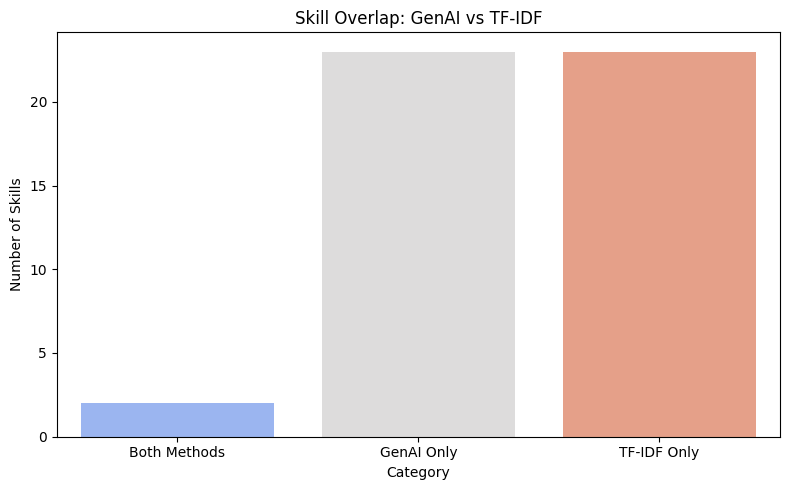

In [29]:
comparison_summary = pd.DataFrame({
    "Category": ["Both Methods", "GenAI Only", "TF-IDF Only"],
    "Count": [len(overlap), len(only_ai), len(only_tfidf)]
})

plt.figure(figsize=(8,5))
sns.barplot(data=comparison_summary, x="Category", y="Count", palette="coolwarm")
plt.title("Skill Overlap: GenAI vs TF-IDF")
plt.ylabel("Number of Skills")
plt.tight_layout()
plt.show()

## Effectiveness, Limitations & Ethics

### Effectiveness
The results of this comparison were honestly more revealing than expected.
TF-IDF surfaced words like "experience", "duties", and "position",  terms
that show up constantly across job postings but don't really tell us
anything about what skills are actually required. GenAI on the other hand
pulled out specific, concrete skills like "python", "aws", "docker", and
"kubernetes", the kind of information that actually helps a job seeker
understand what they need to know.

The fact that the two methods only agreed on "ai" and "ml" isn't a problem, it actually makes sense when you think about it. TF-IDF is essentially
counting and weighing words mathematically, while the LLM is reading and
understanding the text the way a human would. They're doing fundamentally
different things, so it's natural they'd come up with different results.

### Limitations
No approach is perfect, and this one had a few real challenges along the way:

- Getting API access was harder than expected. We hit rate limits on
  Gemini's free tier and had to switch to Groq, which added time to the
  workflow.
- The model occasionally returned malformed JSON, causing 6 out of 200
  rows to fail. This is a good reminder that LLM outputs aren't always
  consistent and need error handling.
- We had to truncate job descriptions to 1000 characters to stay within
  model limits, which means skills mentioned later in longer descriptions
  may have been missed.
- TF-IDF, while fast and simple, doesn't understand language, it just
  sees patterns in numbers, which is why it picks up generic words instead
  of meaningful skills.

### Ethical Considerations
A few things are worth thinking about beyond just the technical results.
Job descriptions themselves aren't neutral — they often reflect the biases
of whoever wrote them, and a model trained on that kind of language can
quietly carry those biases forward. If something like this were used at
scale to filter or rank candidates, it could disadvantage people in ways
that aren't obvious or easy to detect.

It's also important to be transparent that these are AI-generated outputs,
not ground truth. The extracted skills should be treated as a starting
point for analysis, not a definitive answer. Human judgment still matters.

On the privacy side, this project only used publicly available job postings,
so there were no personal data concerns — but that would be a much bigger
issue if resumes or candidate profiles were involved.